### 4-5. 학습 알고리즘 구현하기
---

- *배치 != 미니배치
- 배치는 한 번에 신경망에 넣어서 처리하는 데이터의 묶음
- 미니배치는 전체 학습 데이터를 한 번에 사용하지 않고, 그 중 일부만 뽑아서 학습하는 방법

In [ ]:
# 2층 신경망인 TwoLayerNet을 구성해서 손글씨 숫자를 학습
# params에는 신경망의 학습해야 하는 가중치들과 편향들이 들어가 있고,
# grads에는 가중치나, 편향들의 기울기가 들어있다.
# overfitting이 나는지 안 나는지를 1 epoch마다 평가한다.

import sys, os
import numpy as np
sys.path.insert(
    0,
    os.path.abspath("../deeplearning_from_scratch")
)
from dataset.mnist import load_mnist
from common.functions import *
from common.gradient import numerical_gradient


class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y
    
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis = 1) # axis = 1은 행별로 계산하라는 것을 나타냄.
        t = np.argmax(t, axis = 1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t) # W를 입력으로 넣고, (x, t)를 출력으로 하는 함수

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'] )
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'] )
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'] )
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'] )

        return grads
    
    

(x_train, t_train), (x_test, t_test) = load_mnist(normalize= True, one_hot_label= True)

# 하이퍼파라미터
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100 # 미니배치 크기
learning_rate = 0.1
train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)


network = TwoLayerNet(input_size = 784, hidden_size = 50, output_size = 10)


for i in range(iters_num):
    batch_mask = np.random.choice(train_size , batch_size) # train_size 장수의 이미지에서 batch_size만큼만 뽑는다.
    x_batch = x_train[batch_mask] # batch_mask에서 뽑힌 이미지들을 x_batch에 저장
    t_batch = t_train[batch_mask] # batch_mask에서 뽑힌 이미지들을 x_batch에 저장

    # 기울기 계산(수치 미분법을 써서 많이 오래걸린다.)
    grad = network.numerical_gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)


    # 1 epoch당(600번 반복 됐을 때) epoch : 학습에서 훈련 데이터를 모두 소진했을 때의 횟수
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + " , " + str(test_acc))





train acc, test acc | 0.11236666666666667 , 0.1135


KeyboardInterrupt: 

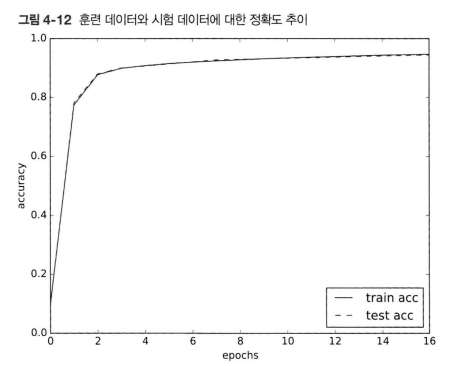
- 결과 그래프
- epochs가 올라갈수록 accuracy가 올라가고 overfitting도 안 나는 것을 확인할 수 있다.

### 정리

- 손실 함수를 기준으로 그 값이 가장 작아지는 가중치 매개변수 값을 찾아내는 것이 신경망 학습의 목표다.

- 가중치 매개변수를 갱신할 때는 가중치 매개변수의 기울기를 이용하고, 기울어진 방향으로 가중치의 값을 갱신하는 작업을 반복한다.

- 수치 미분을 이용한 계산에는 시간이 걸리지만, 그 구현은 간단하다. 다음 장에서 구현하는 오차역전파법은 기울기를 고속으로 구할 수 있다.